# **Notebook 3: Modelling**

> **Objective:** Apply clustering alogrithms to our processed customer dataset `clean_customer_info` in order to find meaningful customer segments to, then, allow the creation of association rules and targeted promotions across the different segments. This notebook functions are defined in the `clustering.py` script.


---

## **Table of Contents**
1. **Imports and Data Loading**
2. **Dense Region on the Geographical Map**
3. **Clustering with Percentages**
    - 3.1. **Feature Selection and Pre-Processing**
        - 3.1.1. **Data Scaling**
    - 3.2. **Determining the Optimal Number of Clusters (K)**
        - 3.2.1. **Elbow Method**
        - 3.2.2. **Silhouette Score**
    - 3.3. **K-Means Algorithm**
        - 3.3.1. **How It Works**
    - 3.4. **Hierarchical Clustering**
        - 3.4.1. **Dendrogram**
        - 3.4.2. **Silhouette Score**
    - 3.5. **K-Means vs Hierarchical Clustering Validation Matrix**
        - 3.5.1. **Adjusted Rand Index**
    - 3.6. **Clustering Visualization**
        - 3.6.1. **t-Distributed Stochastic Neighbor Embedding or TSNE**
        - 3.6.2. **Uniform Manifold Approximation and Projection**
4. **Clustering with Lifetime Spend Values**
    - 4.1. **Determining the Optimal Number of Clusters (K)**
        - 4.1.1. **Elbow Method**
        - 4.1.2. **Silhouette Score**
    - 4.2. **K-Means Algorithm**
    - 4.3. **Hierarchical Algorithm**
    - 4.4. **K-Means vs Hierarchical Clustering Validation Matrix**
        - 4.4.1. **Adjusted Rand Index**
    - 4.5. **Clustering Visualization**
        - 4.5.1. **TSNE**
        - 4.5.2. **UMAP**
5. **Final Segmentation Dataset**

---

## **1. Imports and Data Loading**

In [47]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import confusion_matrix, adjusted_rand_score


from utils import (
    scaling,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette_kmeans,
    plot_silhouette_hierarchical,
    plot_elbow,
    print_silhouette_scores,
    apply_kmeans_perc,
    apply_kmeans_lifetime,
    apply_hierarchical_perc,
    apply_hierarchical_lifetime,
    cluster_groupby,
    dendrogram_visualization
)

In [48]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,year_first_transaction,distinct_stores_visited,number_complaints,typical_hour,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2020,3,1,10,...,0.020065,0.012964,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0
4,Glenda Bauman,female,51,Bsc,1,0,2013,2,0,10,...,0.099442,0.002867,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0
5,Antonio Campbell,male,55,Msc,0,0,2005,2,1,11,...,0.035694,0.098913,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0
7,John Kelling,male,44,Unknown,0,0,2021,1,2,18,...,0.005618,0.137440,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,2021,1,3,17,...,0.014730,0.080746,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0


## **2. Dense Region on the Geographical Map**

From the EDA notebook we could observe that the dense region on the map is not noise, instead it is probably a segment of customers with similar spending behavior or characteristics.

In [49]:
min_lat = 38.7468
max_lat = 38.7488

min_lon = -9.1576
max_lon = -9.1556


dataset['is_dense_geo_area'] = (
    dataset['longitude'].between(min_lon, max_lon) &
    dataset['latitude'].between(min_lat, max_lat)
).astype(int)

dataset['is_dense_geo_area'].value_counts()

is_dense_geo_area
0    30623
1     2415
Name: count, dtype: int64

In [50]:
geo_profile = dataset.groupby('is_dense_geo_area')[
    [
        'customer_age',
        'number_complaints',
        'kids_home',
        'teens_home',
        'percentage_of_products_bought_promotion',


        'lifetime_spend_vegetables',
        'lifetime_spend_meat_fish',
        'lifetime_spend_electronics',
        'lifetime_spend_videogames',
        'lifetime_spend_hygiene',
        'lifetime_spend_alcohol_drinks',
    ]
].mean().T

geo_profile

is_dense_geo_area,0,1
customer_age,56.871600,32.652174
number_complaints,0.842210,2.063768
kids_home,1.044248,2.030228
teens_home,0.925905,0.559420
percentage_of_products_bought_promotion,0.308009,0.501721
lifetime_spend_vegetables,751.870555,215.649275
lifetime_spend_meat_fish,1329.799889,918.877019
lifetime_spend_electronics,2846.105542,954.018219
lifetime_spend_videogames,384.795481,133.415321
lifetime_spend_hygiene,844.432061,402.836025


As we can observe, the customers from the dense geographic region are much more younger, with a high number of complaints, more kids at home, but less teens home, indicating young parents.
Regarding the spending behavior, customers of this area show lower average spending across all categories, except on `lifetime_spend_alcohol_drinks` and on `percentage_of_products_bought_promotion`, which makes sense as most of young adults earn less, therefore spend less and take advantage of promotions more often than older customers.

Therefore, these customers are separated before applying K-Means and are directly assigned to their own cluster, which will be done in the end of the notebook. We are going to separate `dataset` into two different datasets, the one containing the customers from the dense region and the other for the remaining customers, on which we will perform the **segmentation process**. 


In [51]:
geo_cluster_df = dataset[dataset['is_dense_geo_area'] == 1].copy()
modelling_df = dataset[dataset['is_dense_geo_area'] == 0].copy()

## **3. Clustering with Percentages**

To segment customers effectively, we explore different feature representations and clustering techniques.

We begin with a percentage-based feature set to capture relative spending behavior, followed by alternative approaches for comparison. We used silhouette score,  validated with hierarchical clustering and checked the different stats of each clustering and adjusted rand index.

### **3.1. Feature Selection and Pre-Processing**

In [52]:
dataset_perc = modelling_df.copy()

dataset_perc.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'year_first_transaction',
       'distinct_stores_visited', 'number_complaints', 'typical_hour',
       'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_outlier', 'is_dense_geo_area'],
    

For the percentage-based model, we selected demographic variables, promotion sensitivity, complaints, and relative spending proportions.

In [53]:
features_perc = [
    'customer_age',
    'number_complaints',
    'kids_home',
    'teens_home',

    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'perc_spend_hygiene',
    'perc_spend_alcohol'
]

X_perc = dataset_perc[features_perc].copy()
X_perc.columns

Index(['customer_age', 'number_complaints', 'kids_home', 'teens_home',
       'percentage_of_products_bought_promotion', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_tech_entertainment',
       'perc_spend_hygiene', 'perc_spend_alcohol'],
      dtype='object')

##### **3.1.1. Data Scaling**

The data was normalized using **StandardScaler**. Without standardization, features with larger numerical ranges (e.g., `customer_age` or `years_tenure`) would **disproportionately dominate** the distance calculations, lowering the impact of bounded features (such as `percentage_of_products_bought_promotion`, which strictly ranges from 0 to 1).



In [54]:
X_scaled_perc = scaling(X_perc) #Standard Scaler

X_scaled_perc = pd.DataFrame(X_scaled_perc, columns=X_perc.columns, index=X_perc.index)

### **3.2. Determining the Optimal Number of Clusters (K)**

To determine the optimal number of clusters($K$), two strategies were used: the **Elbow Method** and the **Silhouette Score**.

#### **3.2.1. Elbow Method**

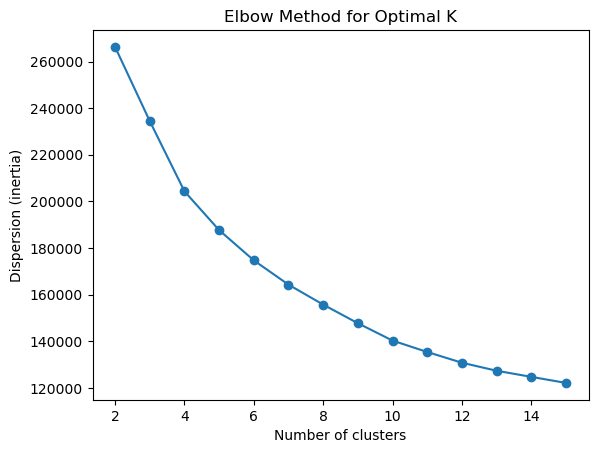

In [55]:
plot_elbow(X_scaled_perc, k_range= 15)

The Elbow Method evaluates the **inertia** to measure cluster compactness. 
As observed in the plot, the inertia decreases smoothly **without** an "elbow" point. This indicates that while the variance continues to drop as K increases, the marginal gain diminishes after the mid-range values.

With all this information, theoretically, the "best" numbers of $K$ would maybe be between 8-10.

##### **3.2.2. Silhouette Score**

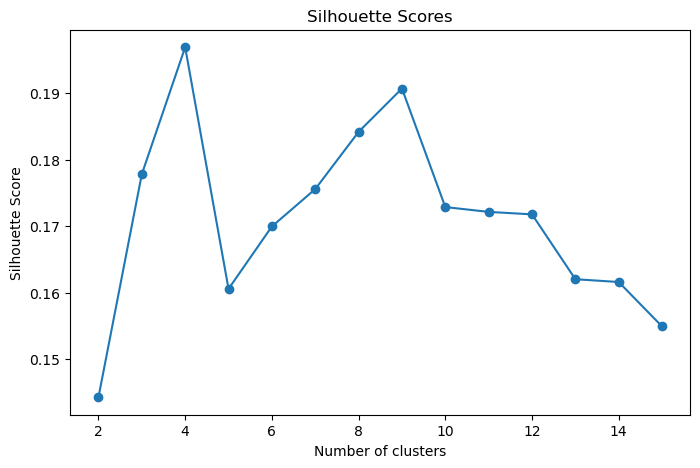

Evaluating Silhouette Scores:
k=6 | silhouette=0.1692
k=7 | silhouette=0.1744
k=8 | silhouette=0.1825
k=9 | silhouette=0.1899


In [56]:
plot_silhouette_kmeans(X_scaled_perc)
print_silhouette_scores(X_scaled_perc, k_values= [6,7,8,9])

The Silhouette Score measures **cluster cohesion**. The plot demonstrates a mathematical peak at lower values (e.g., K=4). However, we decided that selecting K=4 would result in **under-fitting**, as it would not be appropriate to divide the whole dataset in just 2 groups.



### **3.3. K-Means Algorithm**

##### **3.3.1. How it Works**

The first algorithm we used was **K-Means**. Mathematically, it starts by defining $K$ centroids (the central points) in the data space. Then, assigns every customer to the centroid that most closely matches their unique purchasing habits. Through continuous iteration, the algorithm refines these groups until it achieves **maximum similarity inside** each cluster and **maximum variance between** clusters.

By setting the model to **$K=8$**, as defined before, the algorithm identifies nine different profiles that exist in the dataset.

In [57]:
apply_kmeans_perc(X_scaled_perc, dataset_perc, X_perc, k = 8)

Customer Distribution for K=8:
cluster_kmeans_perc
0    2907
1    2422
2    8935
3    2908
4    2199
5    5583
6    2494
7    3175
Name: count, dtype: int64


,n_clusters,8
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [58]:
cluster_groupby(X_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean')

Grouped by mean


cluster_kmeans_perc,0,1,2,3,4,5,6,7
customer_age,56.991056,49.546243,57.887185,57.523384,61.728058,55.845065,57.135124,57.129764
number_complaints,1.054352,0.681668,0.503414,0.765475,2.743065,0.797600,0.860465,0.541732
kids_home,0.254902,0.655244,0.811640,1.039546,1.180991,0.714490,3.796311,1.045984
teens_home,0.303750,0.575557,0.832680,0.907497,1.100045,0.598782,3.013633,0.856693
percentage_of_products_bought_promotion,0.257292,0.378015,0.187018,0.105823,0.291505,0.740652,0.206334,0.157238
perc_spend_vegetables,0.007688,0.034938,0.025928,0.157381,0.024332,0.025334,0.023129,0.092682
perc_spend_meat_fish,0.074060,0.141270,0.056373,0.012114,0.067296,0.069111,0.078515,0.019431
perc_spend_tech_entertainment,0.501867,0.169126,0.072741,0.165456,0.098007,0.072183,0.152711,0.059908
perc_spend_hygiene,0.011112,0.060416,0.032800,0.053536,0.032670,0.030980,0.026047,0.126691
perc_spend_alcohol,0.045888,0.076064,0.016706,0.031815,0.024922,0.018184,0.043498,0.010557


In [59]:
numeric_cols_perc = dataset_perc.select_dtypes(include='number')

cluster_groupby(numeric_cols_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean')

Grouped by mean


cluster_kmeans_perc,0,1,2,3,4,5,6,7
customer_age,56.991056,49.546243,57.887185,57.523384,61.728058,55.845065,57.135124,57.129764
kids_home,0.254902,0.655244,0.811640,1.039546,1.180991,0.714490,3.796311,1.045984
teens_home,0.303750,0.575557,0.832680,0.907497,1.100045,0.598782,3.013633,0.856693
year_first_transaction,2017.009288,2016.200661,2013.931953,2014.643398,2013.902683,2015.070571,2012.957899,2016.283150
distinct_stores_visited,1.509460,3.289017,3.088640,3.215612,3.416098,4.204729,3.231756,3.560630
number_complaints,1.054352,0.681668,0.503414,0.765475,2.743065,0.797600,0.860465,0.541732
typical_hour,17.373237,15.019405,11.228428,14.075309,13.273306,14.116067,10.127506,10.791181
lifetime_total_distinct_products,109.932233,150.356317,175.913710,82.378611,169.113688,137.927458,299.381716,122.394331
percentage_of_products_bought_promotion,0.257292,0.378015,0.187018,0.105823,0.291505,0.740652,0.206334,0.157238
lifetime_spend_groceries,8096.526660,6344.721305,22299.616340,8487.554677,21986.879945,18817.158696,24897.145549,11328.688819


### **3.4. Hierarchical Clustering**

#### **3.4.1. Dendrogram**

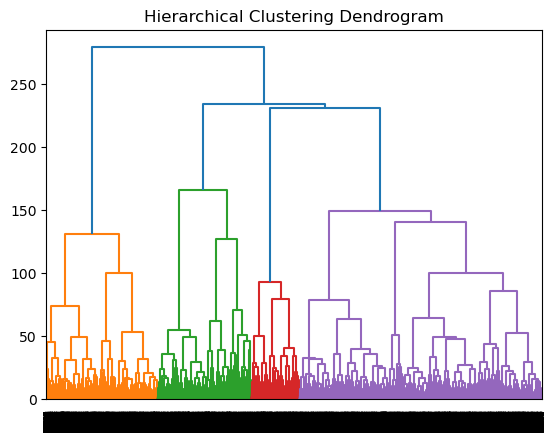

In [60]:
dendrogram_visualization(X_scaled_perc)

#### **3.4.2. Silhouette Score**

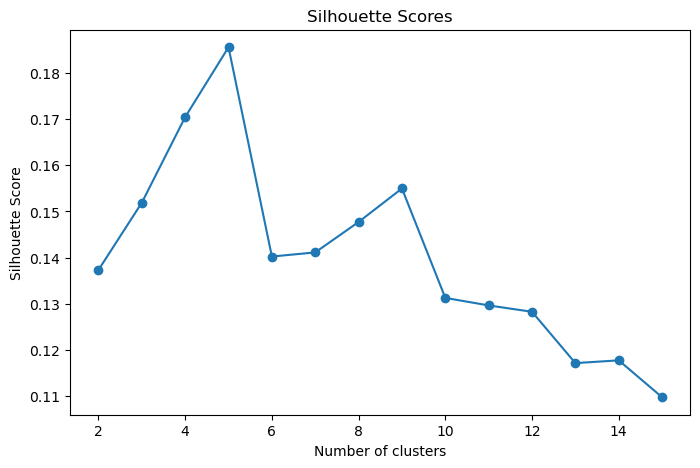

In [61]:
plot_silhouette_hierarchical(X_scaled_perc)

In [63]:
apply_hierarchical_perc(X_scaled_perc, dataset_perc, X_perc, k = 7)

Customer Distribution for K=7:
cluster_agglomerative_perc
0    6897
1    8598
2    2795
3    2971
4    2981
5    5536
6     845
Name: count, dtype: int64


,n_clusters,7
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


### **3.5. K-Means vs Hierarchical Clustering Validation Matrix**

In order to validate the robustness of the segmentation results, we compare the clusters obtained with K-Means against the clusters obtained with Agglomerative Hierarchical Clustering.
The objective is not necessarily for the values to appear on the main diagonal, because cluster labels are arbitrary. For example, K-Means cluster 0 does not need to correspond to Hierarchical cluster 0. 

**What matters is whether each K-Means cluster maps mostly to one specific Hierarchical cluster.**

If most customers from a K-Means cluster are concentrated in a single Hierarchical cluster, this suggests that both algorithms are identifying a similar underlying structure in the data. On the other hand, if one K-Means cluster is spread across many Hierarchical clusters, this indicates weaker agreement and suggests that the segmentation may be less stable.



In [ ]:
pd.DataFrame(
    confusion_matrix(
        dataset_perc['cluster_kmeans_perc'],
        dataset_perc['cluster_agglomerative_perc']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 8)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 8)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster
K-Means 0 Cluster,3080,77,0,0,0,12,9,0
K-Means 1 Cluster,0,231,7,2625,11,29,5,0
K-Means 2 Cluster,833,518,248,25,709,6575,0,0
K-Means 3 Cluster,2,1221,5,15,3964,378,2,0
K-Means 4 Cluster,1,110,2266,1,5,108,4,0
K-Means 5 Cluster,2866,34,0,0,0,28,1,0
K-Means 6 Cluster,3,2039,80,64,17,219,4,0
K-Means 7 Cluster,78,193,94,37,343,686,761,0


#### **3.5.1. Adjusted Rand Index**

The **Adjusted Rand Index** was used to quantify the agreement between the K-Means and Agglomerative Clustering solutions. Unlike a simple comparison of cluster labels, ARI evaluates whether pairs of observations are assigned consistently across both methods.


**Note:**

1 -> Perfect agreement

0.40-0.80 -> Moderate to strong agreement

0-0.40 -> Weak agrerement

0 -> Agreement is approximately what would be expected by chance

< 0 -> Worse agreement than expected by chance.

In [ ]:
ari = adjusted_rand_score(
    dataset_perc['cluster_kmeans_perc'],
    dataset_perc['cluster_agglomerative_perc']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.51


### **3.6. Clustering Visualization**

#### **3.6.1. t-Distributed Stochastic Neighbor Embedding or TSNE**

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_perc)


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


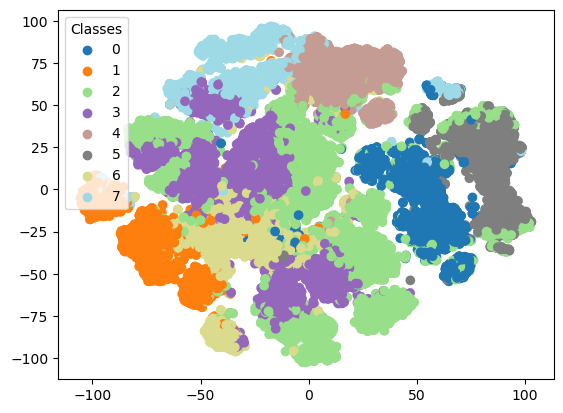

In [ ]:
visualize_dimensionality_reduction(tsne_transformation, dataset_perc['cluster_kmeans_perc'])    


#### **3.6.2. Uniform Manifold Approximation and Projection**

In [ ]:
umap = UMAP(n_neighbors=50, random_state=0)

umap_transformation = umap.fit_transform(X_scaled_perc)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


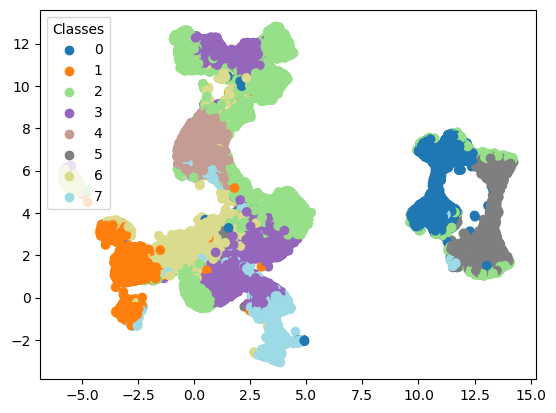

In [ ]:
visualize_dimensionality_reduction(umap_transformation, dataset_perc['cluster_kmeans_perc'])

**Important: Before we assigned any names to each cluster, we first performed clustering with lifetime spend values and found out that it was better, therefore the cluster names will be define below in the notebook.**

## **4. Clustering with Lifetime Spend Values**

In [ ]:
dataset_lifetime = modelling_df.copy()

In [ ]:
features_lifetime = [
    'customer_age',
    'kids_home',
    'teens_home',
    'number_complaints',
    'percentage_of_products_bought_promotion',

    'lifetime_spend_groceries',
    'lifetime_spend_vegetables',
    'lifetime_spend_meat_fish', 
    'lifetime_spend_electronics',
    'lifetime_spend_videogames',
    'lifetime_spend_hygiene',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_petfood'
]

X_lifetime_model = dataset_lifetime[features_lifetime].copy()  
X_lifetime_original = dataset_lifetime[features_lifetime].copy()

In [ ]:
X_scaled_lifetime = scaling(X_lifetime_model) #Standard Scaler

X_scaled_lifetime = pd.DataFrame(
    X_scaled_lifetime,
    columns=X_lifetime_model.columns,
    index=X_lifetime_model.index
)

### **4.1. Determining the Optimal Number of Clusters (K)**

#### **4.1.1. Elbow Method**

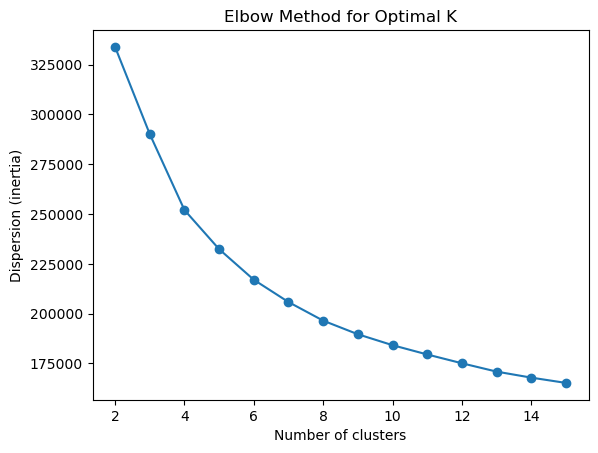

In [ ]:
plot_elbow(X_scaled_lifetime, k_range= 15)

#### **4.1.2. Silhouette Score**

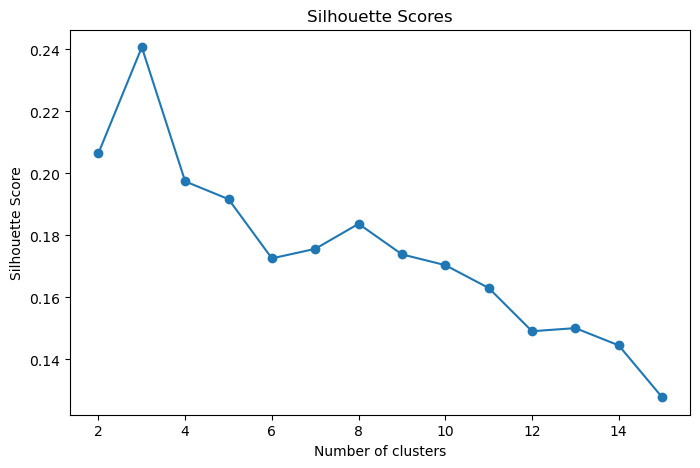

Evaluating Silhouette Scores:
k=7 | silhouette=0.1748
k=8 | silhouette=0.1818
k=9 | silhouette=0.1737
k=10 | silhouette=0.1705


In [ ]:
plot_silhouette_kmeans(X_scaled_lifetime)
print_silhouette_scores(X_scaled_lifetime, k_values= [7,8,9,10])

In [ ]:
X_scaled_lifetime.columns

Index(['customer_age', 'kids_home', 'teens_home', 'number_complaints',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics', 'lifetime_spend_videogames',
       'lifetime_spend_hygiene', 'lifetime_spend_alcohol_drinks',
       'lifetime_spend_petfood'],
      dtype='object')

### **4.2. K-Means Algorithm**

In [ ]:
apply_kmeans_lifetime(X_scaled_lifetime, dataset_lifetime, X_lifetime_original, k = 8)

Customer Distribution for K=8:
cluster_kmeans_lifetime
0    7349
1    3237
2    3197
3    1394
4    5642
5    3741
6    3008
7    3055
Name: count, dtype: int64


,n_clusters,8
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [ ]:
cluster_groupby(X_lifetime_original,cluster_kmeans= 'cluster_kmeans_lifetime', method= 'mean')

Grouped by mean


cluster_kmeans_lifetime,0,1,2,3,4,5,6,7
customer_age,56.228466,56.881372,57.204254,65.769010,54.172988,57.750334,57.419880,57.342717
kids_home,0.679956,0.252703,1.046606,1.246055,0.648706,1.036354,1.032912,3.415385
teens_home,0.729623,0.315107,0.863309,1.249641,0.528181,0.902433,0.876330,2.775123
number_complaints,0.471357,1.068582,0.530810,3.118364,0.772598,0.761026,0.983045,0.870049
percentage_of_products_bought_promotion,0.181494,0.256343,0.156734,0.312459,0.721181,0.107225,0.411536,0.204252
lifetime_spend_groceries,15801.450537,8704.699413,12176.303722,17566.884505,11870.253633,10686.448009,41127.381649,24851.333552
lifetime_spend_vegetables,486.613281,178.604263,1474.280263,528.773314,420.715881,1992.394547,362.800532,818.773813
lifetime_spend_meat_fish,1385.495442,1740.486871,284.327807,1676.621234,1145.305920,170.067362,2020.615691,2777.166612
lifetime_spend_electronics,1340.640767,10060.016682,832.360651,2023.294118,1074.195853,1945.148623,3595.744348,4944.256956
lifetime_spend_videogames,213.531501,1522.789002,147.874570,260.068867,232.572315,228.767175,341.546875,410.614075


In [ ]:
numeric_cols_lifetime = dataset_lifetime.select_dtypes(include='number').drop(['latitude', 'longitude', 'is_customer_outlier','is_dense_geo_area'], axis = 1)

cluster_groupby(numeric_cols_lifetime, cluster_kmeans= 'cluster_kmeans_lifetime', method= 'mean')

Grouped by mean


cluster_kmeans_lifetime,0,1,2,3,4,5,6,7
customer_age,56.228466,56.881372,57.204254,65.769010,54.172988,57.750334,57.419880,57.342717
kids_home,0.679956,0.252703,1.046606,1.246055,0.648706,1.036354,1.032912,3.415385
teens_home,0.729623,0.315107,0.863309,1.249641,0.528181,0.902433,0.876330,2.775123
year_first_transaction,2014.372840,2017.008341,2016.241789,2013.766141,2015.910493,2014.716653,2012.734707,2012.936170
distinct_stores_visited,2.959995,1.483163,3.561464,3.182209,4.196384,3.225341,3.872673,3.235679
number_complaints,0.471357,1.068582,0.530810,3.118364,0.772598,0.761026,0.983045,0.870049
typical_hour,11.167370,17.389558,10.759775,13.418938,14.411379,13.890938,13.278923,10.142390
lifetime_total_distinct_products,160.679412,109.429410,122.661871,152.859397,112.654378,85.161989,251.830452,301.239607
percentage_of_products_bought_promotion,0.181494,0.256343,0.156734,0.312459,0.721181,0.107225,0.411536,0.204252
lifetime_spend_groceries,15801.450537,8704.699413,12176.303722,17566.884505,11870.253633,10686.448009,41127.381649,24851.333552


In [ ]:
cluster_names = {
    0: "Regular Cutomers",
    1: "Gamers",
    2: "Clean & Green",
    3: 'Senior Karens',
    4: "Promotion Lovers",
    5: "Low-Value Occasional Customers",
    6: "High-Value Customers",
    7: "Large Families"
}


dataset_lifetime['cluster_name'] = dataset_lifetime['cluster_kmeans_lifetime'].map(cluster_names)
dataset_lifetime.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,year_first_transaction,distinct_stores_visited,number_complaints,typical_hour,...,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier,is_dense_geo_area,cluster_kmeans_lifetime,cluster_name
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2020,3,1,10,...,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0,0,4,Promotion Lovers
4,Glenda Bauman,female,51,Bsc,1,0,2013,2,0,10,...,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0,0,2,Clean & Green
5,Antonio Campbell,male,55,Msc,0,0,2005,2,1,11,...,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0,0,0,Regular Cutomers
7,John Kelling,male,44,Unknown,0,0,2021,1,2,18,...,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0,0,1,Gamers
8,Arthur Dematteo,male,57,Unknown,0,0,2021,1,3,17,...,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0,0,1,Gamers


### **4.3. Hierarchical Algorithm**

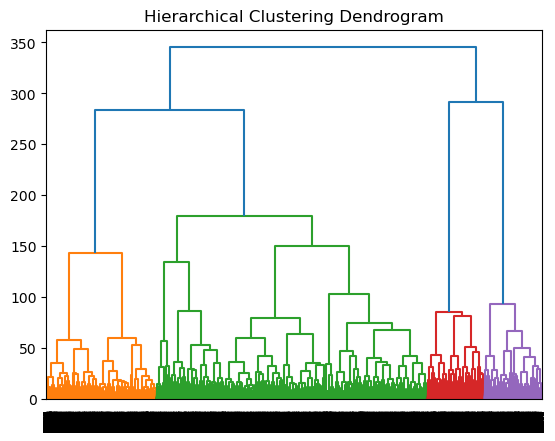

In [64]:
dendrogram_visualization(X_scaled_lifetime)

In [65]:
plot_silhouette_hierarchical(X_scaled_lifetime, K_range=12)

KeyboardInterrupt: 

In [ ]:
apply_hierarchical_lifetime(X_scaled_lifetime, dataset_lifetime, X_lifetime_original, k = 8)

Customer Distribution for K=8:
cluster_agglomerative_lifetime
0    6323
1    3550
2    3517
3    3301
4    3558
5    6236
6    3260
7     878
Name: count, dtype: int64


,n_clusters,8
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


### **4.4. K-Means vs Hierarchical Clustering Validation Matrix**

In [ ]:
pd.DataFrame(
    confusion_matrix(
        dataset_lifetime['cluster_kmeans_lifetime'],
        dataset_lifetime['cluster_agglomerative_lifetime']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 8)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 8)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster
K-Means 0 Cluster,1130,128,92,446,2,5520,28,3
K-Means 1 Cluster,44,3183,7,2,0,1,0,0
K-Means 2 Cluster,1,2,0,23,96,50,3018,7
K-Means 3 Cluster,238,28,94,107,1,82,4,840
K-Means 4 Cluster,4710,100,5,342,1,481,1,2
K-Means 5 Cluster,18,6,2,0,3458,41,208,8
K-Means 6 Cluster,181,101,293,2356,0,58,1,18
K-Means 7 Cluster,1,2,3024,25,0,3,0,0


#### **4.4.1. Adjusted Rand Index**

In [ ]:
ari = adjusted_rand_score(
    dataset_lifetime['cluster_kmeans_lifetime'],
    dataset_lifetime['cluster_agglomerative_lifetime']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.677


The final model uses lifetime spending variables because they capture both customer value and product category intensity. 

Although customer behavior naturally overlaps, the selected solution provides interpretable and commercially actionable segments. The KMeans solution with k=8 was validated against hierarchical clustering, achieving an ARI of 0.677.

This solution will be later combined with the dense geographic cluster identified.

### **4.5. Clustering Visualization**

#### **4.5.1. TSNE**

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_lifetime)

c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


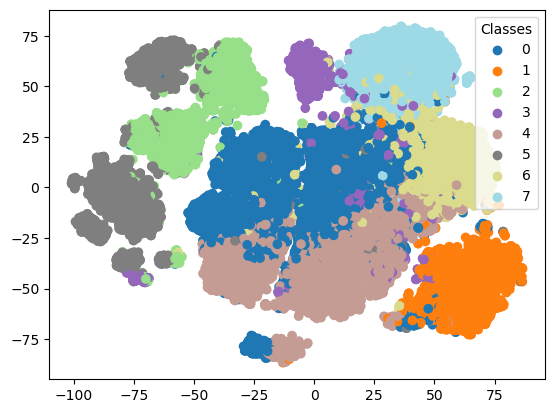

In [ ]:
visualize_dimensionality_reduction(tsne_transformation, dataset_lifetime['cluster_kmeans_lifetime'])    


#### **4.5.2. UMAP**

In [ ]:
umap = UMAP(n_neighbors=50, random_state=0)

umap_transformation = umap.fit_transform(X_scaled_lifetime)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


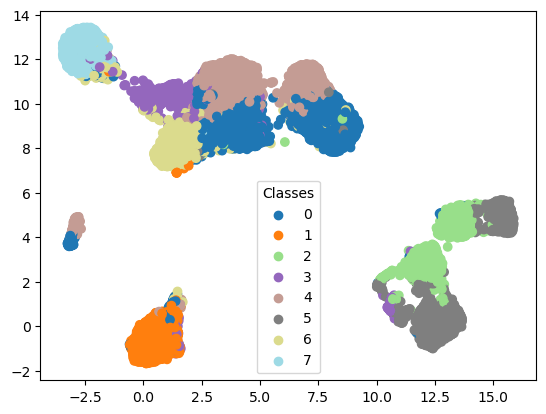

In [ ]:
visualize_dimensionality_reduction(umap_transformation, dataset_lifetime['cluster_kmeans_lifetime'])

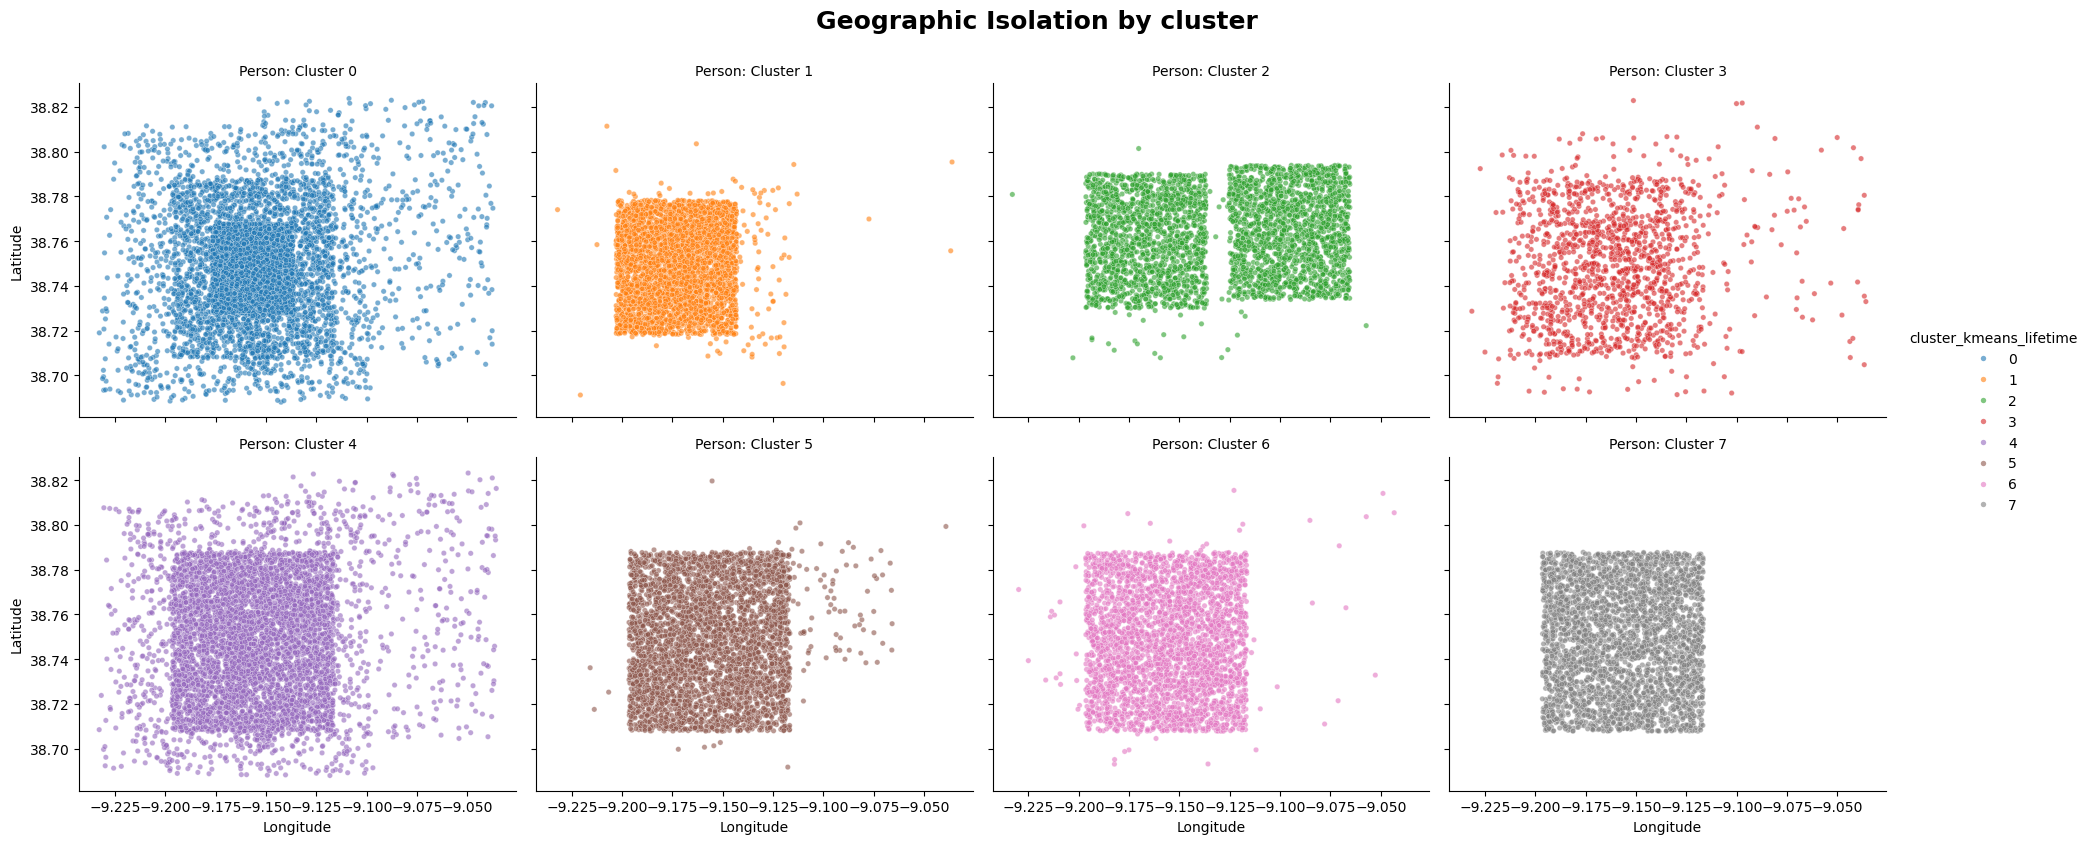

In [ ]:
# Using relplot to create a grid: one map per cluster
g = sns.relplot(
    data=dataset_lifetime,
    x='longitude',
    y='latitude',
    col='cluster_kmeans_lifetime', # This splits the data into separate plots!
    col_wrap=4,           # Defines 4 maps per row
    hue='cluster_kmeans_lifetime',
    palette='tab10',
    s=15,                 # Dot size
    alpha=0.6,            # Transparency
    height=4,             # Height of each individual map
    aspect=1.2            # Width ratio
)

# Formatting for the university report
g.fig.suptitle('Geographic Isolation by cluster', y=1.05, fontsize=18, fontweight='bold')
g.set_axis_labels('Longitude', 'Latitude')
g.set_titles('Person: Cluster {col_name}') # Names each subplot automatically

plt.show()

## **5. Final Segmentation Dataset**

After selecting the **clustering with lifetime spend values** as the final clustering approach, the predefined dense geographic segment is combined with the K-Means clusters obtained from the remaining customers.

In [ ]:
geo_cluster_df['cluster_kmeans_lifetime'] = 8
geo_cluster_df['cluster_name'] = 'Young Karens'

final_clustered_dataset = pd.concat(
    [dataset_lifetime, geo_cluster_df],
    axis=0
).sort_index()

final_clustered_dataset['cluster_kmeans_lifetime'].value_counts().sort_index()

cluster_kmeans_lifetime
0    7349
1    3237
2    3197
3    1394
4    5642
5    3741
6    3008
7    3055
8    2415
Name: count, dtype: int64

In [ ]:
final_clustered_dataset = final_clustered_dataset.reset_index()

In [ ]:
dataset_export = final_clustered_dataset

dataset_export.columns

Index(['customer_id', 'customer_name', 'customer_gender', 'customer_age',
       'education_level', 'kids_home', 'teens_home', 'year_first_transaction',
       'distinct_stores_visited', 'number_complaints', 'typical_hour',
       'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_outlier', 'is_dense_g

In [ ]:
customer_clusters = dataset_export[['customer_id', 'cluster_kmeans_lifetime', 'cluster_name']].copy()

customer_clusters = customer_clusters.rename(
    columns={'cluster_kmeans_lifetime': 'cluster_kmeans'}
)

customer_clusters.to_csv("../data/customer_final_clusters.csv", index=False)

customer_clusters.head()

,customer_id,cluster_kmeans,cluster_name
0,3,4,Promotion Lovers
1,4,2,Clean & Green
2,5,0,Regular Cutomers
3,7,1,Gamers
4,8,1,Gamers
